In [5]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input, Flatten, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import random
import os

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9834 - loss: 0.0705
Test Loss: 0.0704849511384964
Test Accuracy: 0.9833999872207642
Label:  5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Prediction:  5


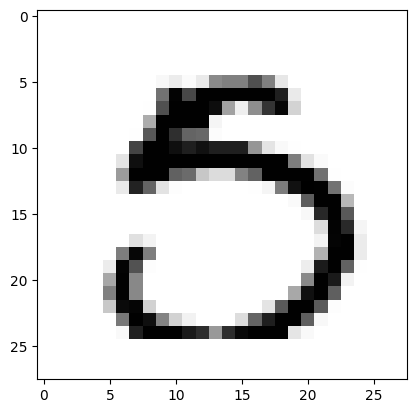

In [10]:
# Using Scope

# Reproducibility
np.random.seed(777)
tf.random.set_seed(777)
random.seed(777)

# Load MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Hyperparameters
learning_rate = 0.001
training_epochs = 15
batch_size = 100
drop_prob = 0.3  # 1-drop_prob during training

# Build model
model = Sequential([
    Input(shape=(784,)),
    Dense(512, activation='relu', kernel_initializer='glorot_normal'),
    Dropout(drop_prob),
    Dense(512, activation='relu', kernel_initializer='glorot_normal'),
    Dropout(drop_prob),
    Dense(512, activation='relu', kernel_initializer='glorot_normal'),
    Dropout(drop_prob),
    Dense(512, activation='relu', kernel_initializer='glorot_normal'),
    Dropout(drop_prob),
    Dense(10, activation='softmax', kernel_initializer='glorot_normal')
])

# Compile
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=learning_rate),
              metrics=['accuracy'])

# Train
model.fit(x_train, y_train, batch_size=batch_size, epochs=training_epochs, verbose=0)

# Evaluate
loss, accuracy = model.evaluate(x_test, y_test)
print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

# Predict one random sample
r = random.randint(0, x_test.shape[0] - 1)
print("Label: ", np.argmax(y_test[r]))
prediction = model.predict(x_test[r:r+1])
print("Prediction: ", np.argmax(prediction))

# Optional: visualize the sample
# import matplotlib.pyplot as plt
plt.imshow(x_test[r].reshape(28,28), cmap='Greys')
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9834 - loss: 0.0705
Test Loss: 0.0704849511384964
Test Accuracy: 0.9833999872207642
Label:  5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Prediction:  5


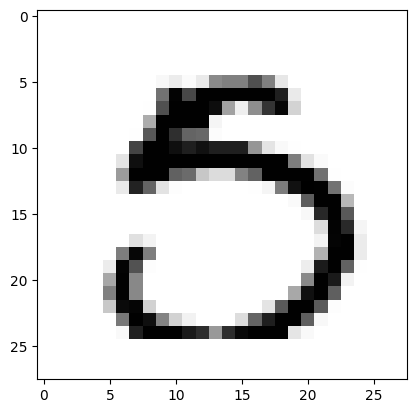

In [11]:
# TensorBoard

# Reproducibility
np.random.seed(777)
tf.random.set_seed(777)
random.seed(777)

# Load MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Hyperparameters
learning_rate = 0.001
training_epochs = 15
batch_size = 100
drop_prob = 0.3  # 1 - keep_prob
tb_log_dir = './tb/mnist'

# Build model
model = Sequential([
    Input(shape=(784,)),
    Dense(512, activation='relu', kernel_initializer='glorot_normal'),
    Dropout(drop_prob),
    Dense(512, activation='relu', kernel_initializer='glorot_normal'),
    Dropout(drop_prob),
    Dense(512, activation='relu', kernel_initializer='glorot_normal'),
    Dropout(drop_prob),
    Dense(512, activation='relu', kernel_initializer='glorot_normal'),
    Dropout(drop_prob),
    Dense(10, activation='softmax', kernel_initializer='glorot_normal')
])

# Compile
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=learning_rate),
              metrics=['accuracy'])

# TensorBoard callback
tensorboard_callback = TensorBoard(log_dir=tb_log_dir, histogram_freq=1, write_graph=True, write_images=True)

# Train
model.fit(x_train.reshape(-1, 784),
          y_train,
          batch_size=batch_size,
          epochs=training_epochs,
          validation_data=(x_test.reshape(-1, 784), y_test),
          callbacks=[tensorboard_callback],
          verbose=0)

# Evaluate
loss, accuracy = model.evaluate(x_test.reshape(-1, 784), y_test)
print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

# Predict one random sample
r = random.randint(0, x_test.shape[0] - 1)
print("Label: ", np.argmax(y_test[r]))
prediction = model.predict(x_test[r:r+1].reshape(1, 784))
print("Prediction: ", np.argmax(prediction))

# Optional: visualize the sample
# import matplotlib.pyplot as plt
plt.imshow(x_test[r], cmap='Greys')
plt.show()

# Run tensorboard in terminal
# tensorboard --logdir=tb/mnist


No checkpoint found. Building new model...

Epoch 1: saving model to ./tb/mnist2_ckpt\model-01.keras

Epoch 2: saving model to ./tb/mnist2_ckpt\model-02.keras

Epoch 3: saving model to ./tb/mnist2_ckpt\model-03.keras

Epoch 4: saving model to ./tb/mnist2_ckpt\model-04.keras

Epoch 5: saving model to ./tb/mnist2_ckpt\model-05.keras

Epoch 6: saving model to ./tb/mnist2_ckpt\model-06.keras

Epoch 7: saving model to ./tb/mnist2_ckpt\model-07.keras

Epoch 8: saving model to ./tb/mnist2_ckpt\model-08.keras

Epoch 9: saving model to ./tb/mnist2_ckpt\model-09.keras

Epoch 10: saving model to ./tb/mnist2_ckpt\model-10.keras

Epoch 11: saving model to ./tb/mnist2_ckpt\model-11.keras

Epoch 12: saving model to ./tb/mnist2_ckpt\model-12.keras

Epoch 13: saving model to ./tb/mnist2_ckpt\model-13.keras

Epoch 14: saving model to ./tb/mnist2_ckpt\model-14.keras

Epoch 15: saving model to ./tb/mnist2_ckpt\model-15.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9834 - loss: 0.0705
Test L

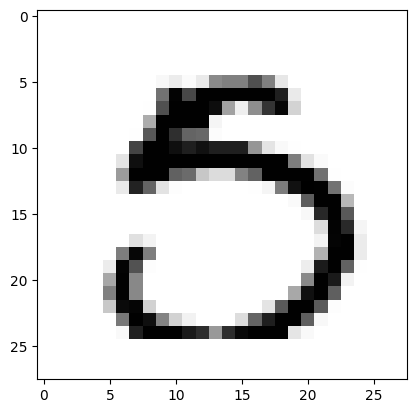

In [12]:
#Saver and Restore 

# Reproducibility
np.random.seed(777)
tf.random.set_seed(777)
random.seed(777)

# Load MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Hyperparameters
learning_rate = 0.001
training_epochs = 15
batch_size = 100
drop_prob = 0.3  # Dropout probability
tb_log_dir = './tb/mnist2'
checkpoint_dir = './tb/mnist2_ckpt'

# Create checkpoint directory
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

# Build model
def build_model():
    model = Sequential([
        Input(shape=(784,)),
        Dense(512, activation='relu', kernel_initializer='glorot_normal'),
        Dropout(drop_prob),
        Dense(512, activation='relu', kernel_initializer='glorot_normal'),
        Dropout(drop_prob),
        Dense(512, activation='relu', kernel_initializer='glorot_normal'),
        Dropout(drop_prob),
        Dense(512, activation='relu', kernel_initializer='glorot_normal'),
        Dropout(drop_prob),
        Dense(10, activation='softmax', kernel_initializer='glorot_normal')
    ])
    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=learning_rate),
                  metrics=['accuracy'])
    return model

# Check if a saved model exists
latest_ckpt = tf.train.latest_checkpoint(checkpoint_dir)
if latest_ckpt:
    print("Restoring model from:", latest_ckpt)
    model = tf.keras.models.load_model(latest_ckpt)
else:
    print("No checkpoint found. Building new model...")
    model = build_model()

# TensorBoard callback
tensorboard_callback = TensorBoard(log_dir=tb_log_dir, histogram_freq=1, write_graph=True)

# ModelCheckpoint callback
checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, "model-{epoch:02d}.keras"),
    save_weights_only=False,
    save_freq='epoch',
    verbose=1
)

# Train
model.fit(x_train.reshape(-1, 784),
          y_train,
          batch_size=batch_size,
          epochs=training_epochs,
          validation_data=(x_test.reshape(-1, 784), y_test),
          callbacks=[tensorboard_callback, checkpoint_callback],
          verbose=0)

# Evaluate
loss, accuracy = model.evaluate(x_test.reshape(-1, 784), y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Predict one random sample
r = random.randint(0, x_test.shape[0] - 1)
print("Label:", np.argmax(y_test[r]))
prediction = model.predict(x_test[r:r+1].reshape(1, 784))
print("Prediction:", np.argmax(prediction))

# Optional: visualize the sample
# import matplotlib.pyplot as plt
plt.imshow(x_test[r], cmap='Greys')
plt.show()

# Run tensorboard in terminal
# tensorboard --logdir tb/mnist2
